<a href="https://colab.research.google.com/github/mgcavallotti/Repositorio-I/blob/main/practica_vectorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sympy_plot_backends
!git clone http://github.com/joaquinr-uner/cvyed
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import collections
import spb
from cvyed import esfera, cilindro, paraboloide, cono

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.3/384.3 kB 7.4 MB/s eta 0:00:00
Cloning into 'cvyed'...
remote: Enumerating objects: 785, done.
remote: Counting objects: 100% (54/54), done.
remote: Compressing objects: 100% (54/54), done.
remote: Total 785 (delta 30), reused 0 (delta 0), pack-reused 731 (from 3)
Receiving objects: 100% (785/785), 222.85 KiB | 7.68 MiB/s, done.
Resolving deltas: 100% (457/457), done.


<Figure size 640x480 with 0 Axes>

In [ ]:
#Funciones
x, y, z = sp.symbols("x y z")


def plano_tangente(f, x0, y0):
  x, y, z = sp.symbols('x y z')

  fx = sp.diff(f, x)
  fy = sp.diff(f, y)

  f0 = f.subs({x: x0, y: y0})
  fx0 = fx.subs({x: x0, y: y0})
  fy0 = fy.subs({x: x0, y: y0})

  plano = sp.Eq(z, f0 + fx0*(x - x0) + fy0*(y - y0))
  return plano


def direccional(f, u):
  x, y, z = sp.symbols('x y z')
  Fx = f.diff(x)
  Fy = f.diff(y)
  gradF = sp.Matrix([Fx,Fy])
  norma = u.norm()
  if norma ==1:
    dir = gradF.dot(u)
  else:
    u2 = u * (1/ (norma))
    dir = gradF.dot(u2)
  return dir


#https://colab.research.google.com/drive/16kUezdH7z2W7r0oeAQ76vgDRBtfVtduW?hl=en-GB#scrollTo=kNTqUsN-NNta









In [2]:
t=sp.symbols('t')
x, y, z = sp.symbols('x y z')
T = sp.Eq(z, 20 + (10 * (1/(sp.exp(0.3 * (x**2 + y**2))))))
r = sp.Matrix([sp.cos(t-2), sp.sin(2*t)])
P= sp.Matrix(r.subs(t, 0.6))

z0 = T.rhs
Tx = z0.diff(x)
Ty = z0.diff(y)
gradT = sp.Matrix([Tx , Ty])
cambioT = gradT.subs({x: P[0] , y: P[1] })

print("El cambio en x es: ", cambioT[0], "El cambio en y es: ", cambioT[1])



El cambio en x es:  -0.779060654085055 El cambio en y es:  -4.27209028495963


La derivada de T en direccion del vector (3,1) desde el punto (1,1) es:  24


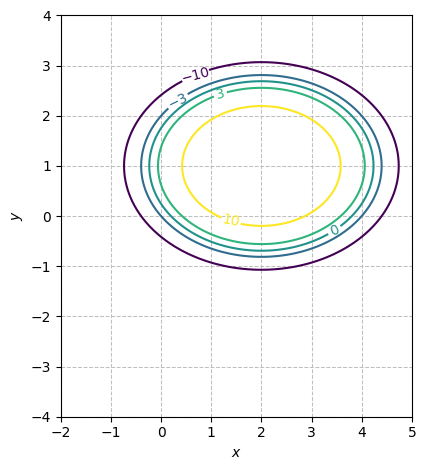

In [9]:
F = 20 - 4*((x-2)**2) - 7*((y-1)**2)
Fx = F.diff(x)
Fy = F.diff(y)
gradF = sp.Matrix([Fx, Fy])
u = gradF.subs({x: 1, y: 1})
v= sp.Matrix([3,1])
norma = v.norm()
v_unit = (1/norma)* v
direccional = u.dot(v)
print("La derivada de T en direccion del vector (3,1) desde el punto (1,1) es: ", direccional)


spb.plot_contour(F , (x, -2 , 5), (y, -4 , 4 ), {"levels": [-10, -3, 0, 3, 10]}, is_filled=False, aspect=(1,1), show=True)


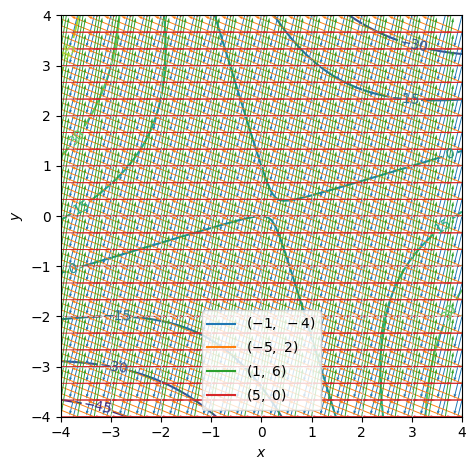

None


In [8]:
G = x**2 -3*x*y +y -y**2

Gx = G.diff(x)
Gy = G.diff(y)

gradG = sp.Matrix([Gx, Gy])

d1 = gradG.subs({x: 1, y: 1})
d2 = gradG.subs({x: -1, y: 1})
d3 = gradG.subs({x: -1, y: -1})
d4 = gradG.subs({x: 1, y: -1})


p1 = G.subs({x:1 , y: 1})
p2 = G.subs({x:-1 , y: 1})
p3 = G.subs({x: -1 , y: -1})
p4 = G.subs({x: 1, y: -1 })


h = spb.plot_contour(G, (x, -4, 4), (y, -4, 4), levels= [p1, p2, p3, p4], is_filled=False, show=False, aspect = (1,1))

vec1 = spb.plot_vector(d1, (x, -4, 4), (y, -4, 4), quiver_kw={"scale": 50,'cmap':'cool'},scalar=False,use_cm=False, aspect = (1,1), show=False)
vec2 = spb.plot_vector(d2, (x, -4, 4), (y, -4, 4), quiver_kw={"scale": 50,'cmap':'cool'},scalar=False,use_cm=False, aspect = (1,1), show=False)
vec3 = spb.plot_vector(d3, (x, -4, 4), (y, -4, 4), quiver_kw={"scale": 50,'cmap':'cool'},scalar=False,use_cm=False, aspect = (1,1), show=False)
vec4 = spb.plot_vector(d4, (x, -4, 4), (y, -4, 4), quiver_kw={"scale": 50,'cmap':'cool'},scalar=False,use_cm=False, aspect = (1,1), show=False)

r = (h+vec1+vec2+vec3+vec4).show()

#suma de graficas vec y h
print(r)
